# Bubble Plots

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


--2025-02-15 12:55:58--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  1.63MB/s    in 63s     

2025-02-15 12:57:03 (2.40 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



In [40]:
df = pd.read_csv("survey-data.csv")
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


# Exploring Data Distributions Using Bubble Plots
Bubble Plot for Age vs. Frequency of Participation
Visualize the relationship between respondents’ age and their participation frequency (SOPartFreq) using a bubble plot.
Use the size of the bubbles to represent their job satisfaction (JobSat).

In [41]:
df_cleaned = df.dropna(subset=['Age', 'SOPartFreq', 'JobSat'])

In [42]:
df_cleaned.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
10,11,"I used to be a developer by profession, but no...",35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Written Tutorial...,...,25.0,10.0,0.0,15.0,0.0,0.0,Appropriate in length,Easy,NaN,8.0
12,13,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,NaN,...,30.0,0.0,0.0,20.0,10.0,10.0,Appropriate in length,Easy,NaN,8.0
15,16,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,5.0
18,19,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Books;Stack Over...,...,60.0,10.0,10.0,0.0,0.0,0.0,Appropriate in length,Easy,NaN,10.0
20,21,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Other online resources (e.g., videos, blogs, f...",Written Tutorials;Stack Overflow;Interactive t...,...,100.0,90.0,90.0,100.0,90.0,100.0,Appropriate in length,Easy,NaN,6.0


In [43]:
df['JobSat'].value_counts()

JobSat
8.0     7509
7.0     6379
6.0     3751
9.0     3626
10.0    2251
5.0     1956
3.0     1165
4.0     1130
2.0      772
0.0      311
1.0      276
Name: count, dtype: int64

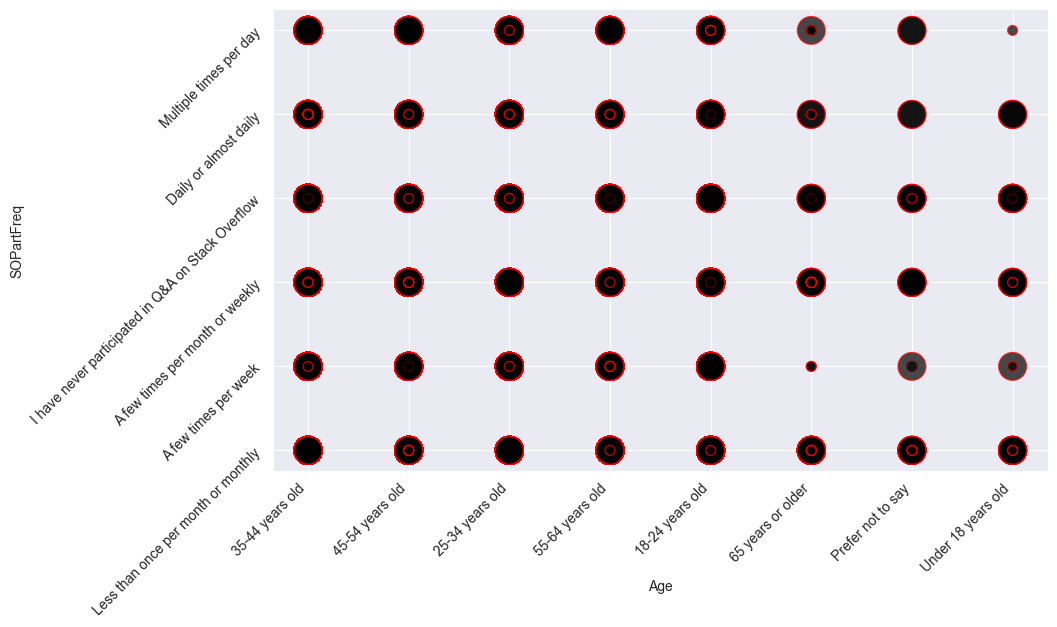

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(
    x=df_cleaned['Age'],
    y=df_cleaned['SOPartFreq'],
    s=df_cleaned['JobSat'],
    alpha=0.7,
    sizes=(50, 400),
    edgecolors='red',
    color='black'
)
plt.xlabel('Age')
plt.ylabel('SOPartFreq')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, ha='right')
plt.show()

# Bubble Plot for Compensation vs. Job Satisfaction
-Visualize the relationship between yearly compensation (ConvertedCompYearly) and job satisfaction (JobSat).

Use the size of the bubbles to represent respondents’ age.

In [46]:
age_counts = df_cleaned['Age'].value_counts()
age_counts

Age
25-34 years old       9980
35-44 years old       6834
18-24 years old       2966
45-54 years old       2565
55-64 years old        844
65 years or older      101
Under 18 years old      59
Prefer not to say       39
Name: count, dtype: int64

In [25]:
import re
import numpy as np


def convert_age(column: str) -> int:
    if isinstance(column, str):
        if 'older' in column:
            match = re.search(r'\d+', column)
            if match:
                return float(match.group()) + 1
        elif 'Under' in column:
            match = re.search(r'\d+', column)
            if match:
                return float(match.group()) - 1
        elif 'Prefer not' in column:
            return np.nan
        else:
            match = re.findall(r'\d+', column)
            if match:
                return sum(float(i) for i in match) / len(match)

In [47]:
df['Age'] = df['Age'].apply(convert_age)

In [48]:
df_cleaned_age = df.dropna(subset=['ConvertedCompYearly', 'JobSat', 'Age'])

In [49]:
df_cleaned_age.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
72,73,I am a developer by profession,21.0,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,65.0,100.0,100.0,100.0,50.0,90.0,Too long,Easy,7322.0,10.0
379,380,I am a developer by profession,39.5,"Employed, full-time",Remote,Apples,Hobby;Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Social Media;Wri...,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,Difficult,91295.0,10.0
389,390,I am a developer by profession,29.5,"Employed, full-time;Student, part-time",Remote,Apples,Hobby;School or academic work,Some college/university study without earning ...,Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Coding sessio...,...,20.0,30.0,5.0,20.0,10.0,5.0,Too long,Easy,110000.0,10.0
392,393,I am a developer by profession,39.5,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media,NaN,...,30.0,5.0,10.0,0.0,0.0,5.0,Appropriate in length,Neither easy nor difficult,161044.0,7.0
398,399,I am a developer by profession,49.5,"Employed, full-time",Remote,Apples,Hobby;Other (please specify):,Some college/university study without earning ...,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,30.0,10.0,30.0,0.0,0.0,0.0,Appropriate in length,Easy,195000.0,5.0


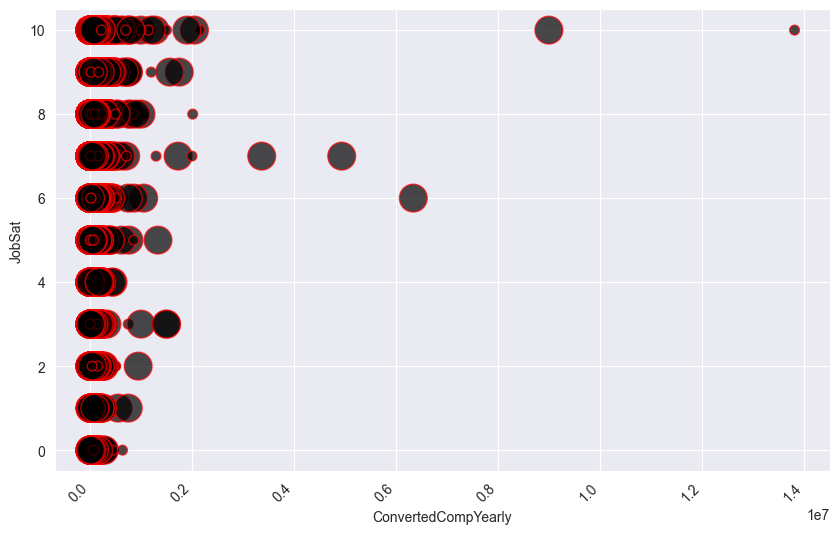

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(
    x=df_cleaned_age['ConvertedCompYearly'],
    y=df_cleaned_age['JobSat'],
    s=df_cleaned_age['Age'],
    alpha=0.7,
    sizes=(50, 400),
    edgecolors='red',
    color='black'
)
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSat')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualizing Technology Trends Using Bubble Plots
 ### Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction
Explore the relationship between preferred web frameworks (WebframeWantToWorkWith) and job satisfaction.

Use bubble size to represent the number of respondents.

In [66]:
df_tech_grouped = df_cleaned_age.groupby('WebframeWantToWorkWith').agg(
    RespondentCount = ('WebframeWantToWorkWith', 'count'),
    avgJobSat = ('JobSat', 'mean'),
).reset_index()
top_web_frameworks = df_tech_grouped.sort_values(by='RespondentCount', ascending=False).head(15)

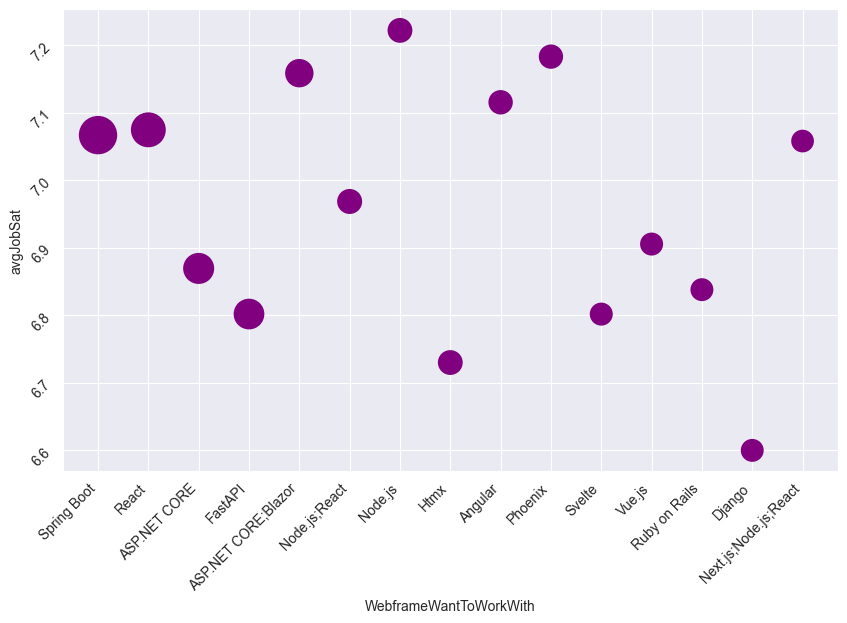

In [70]:
plt.figure(figsize=(10, 6))
plt.scatter(
    x=top_web_frameworks['WebframeWantToWorkWith'],
    y=top_web_frameworks['avgJobSat'],
    s=top_web_frameworks['RespondentCount'] * 2,  
    alpha=1,
    c='purple',
    linewidths=2,  
)
plt.xlabel('WebframeWantToWorkWith')
plt.ylabel('avgJobSat')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, ha='right')
plt.show()

# Bubble Plot for Preferred Databases vs. Job Satisfaction
Explore the relationship between preferred databases (DatabaseWantToWorkWith) and job satisfaction.

Use bubble size to indicate the number of respondents for each database.

In [76]:
df_exploded = df_cleaned_age[['DatabaseWantToWorkWith', 'JobSat']].copy()
df_exploded['DatabaseWantToWorkWith'] = df_exploded['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_exploded.explode('DatabaseWantToWorkWith')
df_exploded = df_exploded.dropna(subset=['DatabaseWantToWorkWith'])

In [86]:
df_db_grouped = df_exploded.groupby('DatabaseWantToWorkWith').agg(
    RespondentCount = ('DatabaseWantToWorkWith', 'count'),
    avgJobSat = ('JobSat', 'mean'),
).reset_index()
df_db_grouped = df_db_grouped.sort_values(by='RespondentCount', ascending=False).head(15)

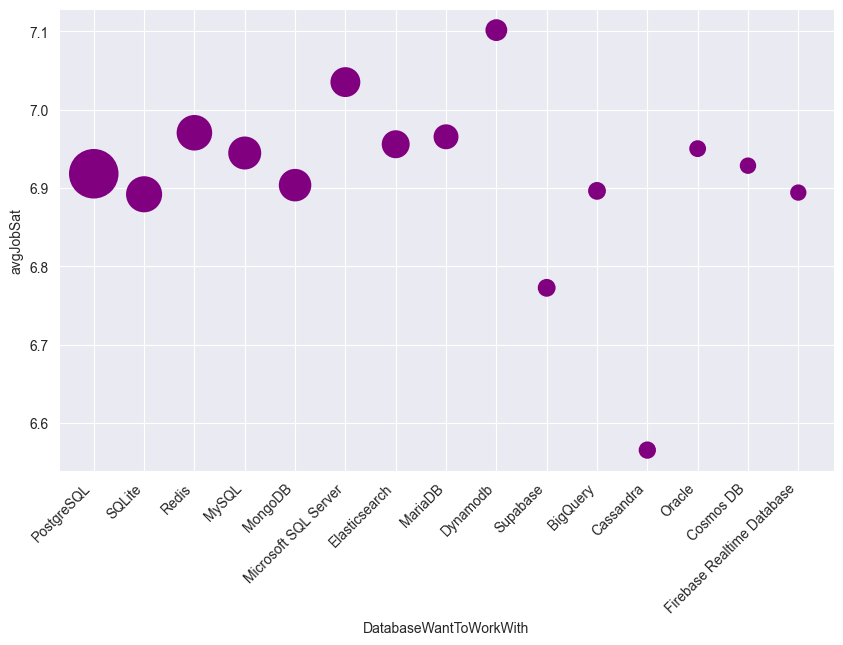

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(
    x=df_db_grouped['DatabaseWantToWorkWith'],
    y=df_db_grouped['avgJobSat'],
    s=df_db_grouped['RespondentCount'] * .15,
    alpha=1,
    c='purple',
    linewidths=2, 
)
plt.xlabel('DatabaseWantToWorkWith')
plt.ylabel('avgJobSat')
plt.xticks(rotation=45, ha='right')
plt.show()

# Bubble Plot for Compensation Across Developer Roles
Visualize compensation (ConvertedCompYearly) across different developer roles (DevType).

Use bubble size to represent job satisfaction.

In [142]:
df_agg_devType = df_cleaned.groupby('DevType').agg(
    RespondentCount = ('DevType', 'count'),
    avgJobSat = ('JobSat', 'mean'),
    avgCom = ('ConvertedCompYearly', 'mean'),
).reset_index()
df_agg_devType = df_agg_devType.dropna(subset=['DevType', 'avgJobSat', 'avgCom'])
df_agg_devType = df_agg_devType.sort_values(by='avgCom', ascending=True)
df_agg_devType.head(5)

,DevType,RespondentCount,avgJobSat,avgCom
32,Student,115,6.478261,27200.425532
0,Academic researcher,334,6.847305,56425.127778
33,System administrator,144,6.500000,59496.196970
24,Marketing or sales professional,17,6.588235,65537.000000
20,Educator,100,6.540000,65643.900000


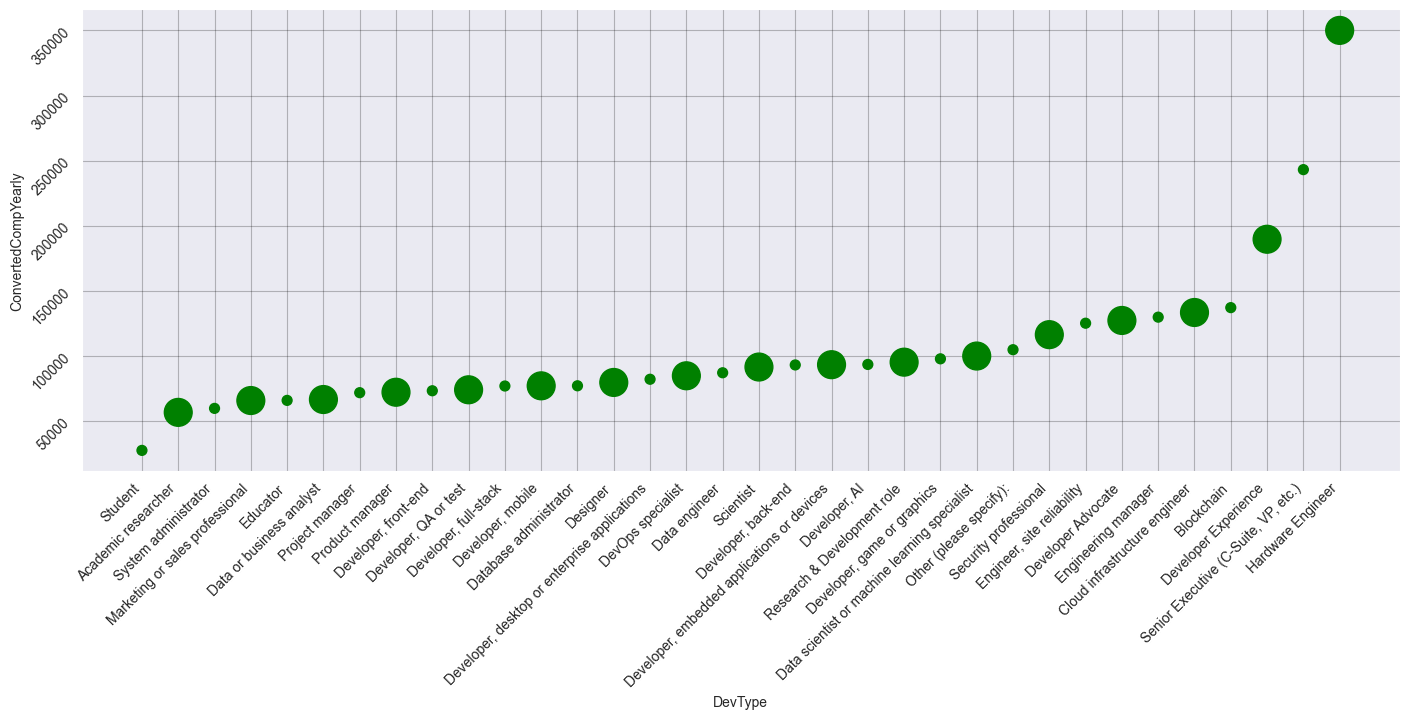

In [143]:
plt.figure(figsize=(17, 6))
plt.scatter(
    x=df_agg_devType['DevType'],
    y=df_agg_devType['avgCom'],
    s=df_agg_devType['RespondentCount'],
    alpha=1,
    sizes=(50, 400),
    edgecolors='green',
    color='green'
)
plt.xlabel('DevType')
plt.ylabel('ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45, ha='right')
plt.grid(True, linestyle='-', alpha=0.25, color='black')
plt.show()